# 서울시 골목상권 폐업위험 조기경보 — 예측 모델링과 해석

> **핵심 질문** — 다음 분기에 점포 순감소(폐업 > 개업)로 전환될 상권 × 업종은 어디이며, 무엇이 위험을 만드는가

앞 노트북(`상권_폐업위험_데이터준비_EDA.ipynb`)이 만든 `04_model_input.csv`를 입력으로 받아
**모델 선정 → 불균형 처리 → 검증 → 해석 → 테스트 분기 예측** 까지를 다룸.

## 시점 분할

| 구분 | 분기 | 칸수(예상) | 쓰는 곳 |
|---|---|---|---|
| 학습 | 2023Q1 ~ 2025Q2 | 약 56,500 | 모델 학습 |
| 검증 | 2025Q3 | 약 5,500 | 모델 선정 · 임계값 결정 |
| 테스트 | 2025Q4 | 약 5,479 | 최종 성능 보고 (마지막에 한 번만) |

각 분기는 **그 다음 분기의 결과로 채점**함. 무작위로 섞지 않고 시간 순서로 자름.

## 이 노트북에서 내린 판단

1. **모델은 XGBoost** — 의사결정나무 · 랜덤포레스트 · 로지스틱 회귀 · 선형 SVM 과 같은 검증 분기에서
   비교한 뒤 고름. 참고문헌(코로나19 전후 요식업 폐업예측)도 같은 5종 비교에서 XGBoost를 선택했음.
2. **불균형 처리는 오버샘플링이 아니라 `scale_pos_weight`** — 분할 **이전**에 오버샘플링하면
   복제된 소수 클래스가 학습과 검증에 함께 들어가 성능이 부풀려짐. 가중치는 그 위험이 없음.
3. **정확도를 주지표로 쓰지 않음** — 양성률이 26% 정도인 소수 사건이므로 PR-AUC와 Lift로 판정함.
4. **상권 식별 정보를 피처에서 뺌** — `상권_코드` · 좌표 · 행정동을 넣으면 모델이 상권을 외움.
   목적이 «어떤 조건이 위험을 만드는가»이므로 **성격 변수만** 남김.
5. **시간 변수를 피처에서 뺌** — 분기 번호·계절은 한 분기 안에서 모든 칸이 같은 값이라
   그 분기 안의 순위를 바꾸지 못함. 전국 단위 경제지표를 뺀 것과 같은 이유임.
6. **`상권_변화_지표`는 피처가 아니라 기준선** — 폐업 정보로 만들어져 라벨과 원천이 같음.


---
# 1. 적재와 시점 분할


In [1]:
import os, gc, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (average_precision_score, roc_auc_score, f1_score,
                             precision_score, recall_score, accuracy_score,
                             confusion_matrix, precision_recall_curve)
from xgboost import XGBClassifier
import shap

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 80)

for cand in ["C:/Windows/Fonts/malgun.ttf", "/System/Library/Fonts/AppleSDGothicNeo.ttc"]:
    if Path(cand).exists():
        fm.fontManager.addfont(cand)
        plt.rcParams["font.family"] = fm.FontProperties(fname=cand).get_name()
        break
plt.rcParams["axes.unicode_minus"] = False

PROC = Path("data/processed"); FIG = Path("figures"); FIG.mkdir(exist_ok=True)
SEED = 42

Q_TRAIN = [20231, 20232, 20233, 20234, 20241, 20242, 20243, 20244, 20251, 20252]
Q_VALID = [20253]
Q_TEST  = [20254]

d = pd.read_csv(PROC / "04_model_input.csv", encoding="utf-8-sig")
print(f"입력 {d.shape} · 분기 {d['기준_년분기_코드'].nunique()}개 · 양성률 {d['y'].mean():.1%}")
display(d.groupby("기준_년분기_코드")["y"].agg(칸수="size", 순감소율="mean").round(3).T)

C:\Users\지선호\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


입력 (67475, 67) · 분기 12개 · 양성률 25.5%


기준_년분기_코드,20231,20232,20233,20234,20241,20242,20243,20244,20251,20252,20253,20254
칸수,5706.000,5731.000,5701.000,5730.000,5706.000,5678.000,5622.000,5586.000,5534.000,5502.00,5500.000,5479.00
순감소율,0.229,0.261,0.223,0.236,0.254,0.276,0.262,0.284,0.261,0.26,0.253,0.26


## 1-1. 피처 정의

**빼는 것**을 먼저 정함. 뺀 이유가 없는 변수만 남김.

| 빼는 변수 | 이유 |
|---|---|
| `y` · `다음상태` · `사건_다음` | 라벨 그 자체 |
| `상권_변화_지표` · `기준선_위험` | 폐업 정보로 만들어진 지표 — 기준선으로만 씀 |
| `상권_코드` · `상권_코드_명` · 좌표 · `행정동` | 상권 식별 정보 — 모델이 상권을 외우게 됨 |
| `기준_년분기_코드` · `분기idx` | 시간 축 — 한 분기 안에서 상수이므로 순위에 기여 못 함 |
| `규모구간` | 전체 표본으로 나눈 구간이라 테스트 정보가 섞임. 층화 평가에만 씀 |

`개업_점포_수` · `폐업_점포_수` · `순감소_현재` 는 **현재 분기(t)** 값이므로 남김.
라벨은 t+1 이라 시점이 다름.


In [2]:
DROP = ["y", "다음상태", "사건_다음",
        "상권_변화_지표", "기준선_위험",
        "상권_코드", "상권_코드_명", "행정동_코드", "행정동", "서비스_업종_코드",
        "엑스좌표_값", "와이좌표_값",
        "기준_년분기_코드", "분기idx", "규모구간"]
CAT = ["상권유형", "자치구", "서비스_업종_코드_명"]

FEATS = [c for c in d.columns if c not in DROP]
NUM = [c for c in FEATS if c not in CAT]
print(f"피처 {len(FEATS)}개 = 수치 {len(NUM)} + 범주 {len(CAT)}")

X_all = pd.get_dummies(d[FEATS], columns=CAT, drop_first=False)
X_all = X_all.astype(float)
y_all = d["y"].astype(int)
print(f"원-핫 후 {X_all.shape[1]}개 열")

m_tr = d["기준_년분기_코드"].isin(Q_TRAIN)
m_va = d["기준_년분기_코드"].isin(Q_VALID)
m_te = d["기준_년분기_코드"].isin(Q_TEST)

Xtr, ytr = X_all[m_tr], y_all[m_tr]
Xva, yva = X_all[m_va], y_all[m_va]
Xte, yte = X_all[m_te], y_all[m_te]

# 결측은 트리 계열은 그대로 두고, 선형 모델용으로만 중앙값 대체본을 따로 둠
med = Xtr.median()
Xtr_f, Xva_f, Xte_f = Xtr.fillna(med), Xva.fillna(med), Xte.fillna(med)

for nm, Xs, ys in [("학습", Xtr, ytr), ("검증", Xva, yva), ("테스트", Xte, yte)]:
    print(f"  {nm}  {len(Xs):>7,}칸 · 양성률 {ys.mean():.1%}")
print(f"\n결측 있는 열 {int((Xtr.isna().sum() > 0).sum())}개 (매출 계열)")

피처 52개 = 수치 49 + 범주 3
원-핫 후 88개 열
  학습   56,496칸 · 양성률 25.4%
  검증    5,500칸 · 양성률 25.3%
  테스트    5,479칸 · 양성률 26.0%

결측 있는 열 29개 (매출 계열)


---
# 2. 기준선 — 모델이 넘어야 하는 선

EDA 5-1과 **같은 규칙**을 검증·테스트 분기에 다시 적용함.
`Lift = 정밀도 ÷ 기저율` 이고 1.0이면 아무렇게나 찍는 것과 같음.
(Lift 1.5 = 아무렇게나 찍을 때보다 1.5배 잘 맞힘)


In [3]:
def lift_row(y_true, pred, name):
    y_true = np.asarray(y_true); pred = np.asarray(pred)
    n1 = int(pred.sum()); base = y_true.mean()
    tp = int(((pred == 1) & (y_true == 1)).sum())
    prec = tp / n1 if n1 else np.nan
    rec = tp / int(y_true.sum()) if y_true.sum() else np.nan
    return {"방법": name, "위험으로 찍은 수": n1, "정밀도": prec, "재현율": rec,
            "Lift": prec / base if base else np.nan}

rows = []
for nm, msk in [("검증 2025Q3", m_va), ("테스트 2025Q4", m_te)]:
    s = d[msk]
    k = int(s["순감소_현재"].sum())
    pred_size = np.zeros(len(s), dtype=int)
    pred_size[np.argsort(-s["전체_점포_수"].values, kind="stable")[:k]] = 1
    for r in [lift_row(s["y"], np.ones(len(s), int), "무작위(전부 위험)"),
              lift_row(s["y"], s["순감소_현재"].values, "직전 분기"),
              lift_row(s["y"], s["기준선_위험"].fillna(0).values, "상권변화지표(HL)"),
              lift_row(s["y"], pred_size, f"점포 수(상위 {k:,}칸)")]:
        r["분기"] = nm; rows.append(r)

BASE = pd.DataFrame(rows)[["분기", "방법", "위험으로 찍은 수", "정밀도", "재현율", "Lift"]]
BASE[["정밀도", "재현율", "Lift"]] = BASE[["정밀도", "재현율", "Lift"]].round(3)
display(BASE.set_index(["분기", "방법"]))
print(f"기저율  검증 {yva.mean():.1%} · 테스트 {yte.mean():.1%}")
print("→ 모델은 이 표의 Lift를 넘어야 의미가 있음")

위험으로 찍은 수    정밀도    재현율   Lift
분기         방법                                             
검증 2025Q3  무작위(전부 위험)            5500  0.253  1.000  1.000
           직전 분기                 1326  0.296  0.282  1.171
           상권변화지표(HL)             998  0.251  0.180  0.990
           점포 수(상위 1,326칸)       1326  0.416  0.396  1.642
테스트 2025Q4 무작위(전부 위험)            5479  0.260  1.000  1.000
           직전 분기                 1285  0.311  0.281  1.199
           상권변화지표(HL)             974  0.243  0.167  0.937
           점포 수(상위 1,285칸)       1285  0.427  0.386  1.645

기저율  검증 25.3% · 테스트 26.0%
→ 모델은 이 표의 Lift를 넘어야 의미가 있음


---
# 3. 분류 모델 5종 비교

참고문헌과 같은 구성으로 비교함 — 의사결정나무 · 랜덤포레스트 · 로지스틱 회귀 · XGBoost · SVM.
SVM은 표본이 5만 건이라 커널 SVM이 실용적이지 않으므로 **선형 SVM(LinearSVC)** 으로 대신함.

**불균형은 가중치로 다룸.** 모든 모델에 `class_weight="balanced"` (XGBoost는 `scale_pos_weight`)를 줘서
조건을 같게 맞춤. 오버샘플링을 쓰지 않는 이유는 표지 판단 2번에 있음.

주지표는 **PR-AUC**. 양성이 26% 뿐인 소수 사건이라 정확도는 «전부 0으로 찍기»에도 74%가 나옴.


In [4]:
pos_w = float((ytr == 0).sum() / (ytr == 1).sum())
print(f"양성 가중치 scale_pos_weight = {pos_w:.3f}")

MODELS = {
    "의사결정나무": (DecisionTreeClassifier(max_depth=6, min_samples_leaf=50,
                                     class_weight="balanced", random_state=SEED), "fill"),
    "랜덤포레스트": (RandomForestClassifier(n_estimators=400, max_depth=14, min_samples_leaf=20,
                                     class_weight="balanced", n_jobs=-1, random_state=SEED), "fill"),
    "로지스틱 회귀": (make_pipeline(StandardScaler(),
                                LogisticRegression(max_iter=3000, class_weight="balanced",
                                                   random_state=SEED)), "fill"),
    "선형 SVM":    (make_pipeline(StandardScaler(),
                                LinearSVC(C=0.1, class_weight="balanced", max_iter=5000,
                                          random_state=SEED)), "fill"),
    "XGBoost":    (XGBClassifier(n_estimators=600, learning_rate=0.05, max_depth=6,
                                 subsample=0.8, colsample_bytree=0.8,
                                 min_child_weight=5, reg_lambda=1.0,
                                 scale_pos_weight=pos_w, eval_metric="aucpr",
                                 tree_method="hist", n_jobs=-1, random_state=SEED), "raw"),
}

def score_of(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)          # LinearSVC

fitted, rows = {}, []
for name, (mdl, mode) in MODELS.items():
    A, B = (Xtr_f, Xva_f) if mode == "fill" else (Xtr, Xva)
    mdl.fit(A, ytr)
    s = score_of(mdl, B)
    pred = (s >= np.quantile(s, 1 - yva.mean())) .astype(int)   # 기저율과 같은 비율만 위험으로 찍음
    rows.append({"모델": name,
                 "PR-AUC": average_precision_score(yva, s),
                 "ROC-AUC": roc_auc_score(yva, s),
                 "F1": f1_score(yva, pred),
                 "정밀도": precision_score(yva, pred, zero_division=0),
                 "재현율": recall_score(yva, pred),
                 "정확도": accuracy_score(yva, pred),
                 "Lift": precision_score(yva, pred, zero_division=0) / yva.mean()})
    fitted[name] = (mdl, mode)
    print(f"  [완료] {name}")

CMP = pd.DataFrame(rows).set_index("모델").round(3).sort_values("PR-AUC", ascending=False)
display(CMP)

TOP  = CMP.index[0]
BEST = "XGBoost"          # 과제 결정 — 참고문헌과 같은 구성(5종 비교 → XGBoost → SHAP)으로 고정
print(f"검증 PR-AUC 1위 = {TOP} ({CMP.loc[TOP,'PR-AUC']:.3f})")
print(f"채택 모델      = {BEST} ({CMP.loc[BEST,'PR-AUC']:.3f})")
if TOP != BEST:
    print(f"→ {BEST}는 이 표에서 1위가 아님 (차이 {CMP.loc[TOP,'PR-AUC']-CMP.loc[BEST,'PR-AUC']:+.3f}). "
          f"7장 최종 평가에서 {TOP}와 나란히 보고함.")
print(f"참고: 전부 0으로 찍어도 정확도는 {1-yva.mean():.1%} 임 — 정확도로 고르면 안 되는 이유")

양성 가중치 scale_pos_weight = 2.930


  [완료] 의사결정나무


  [완료] 랜덤포레스트


  [완료] 로지스틱 회귀


  [완료] 선형 SVM


  [완료] XGBoost


,PR-AUC,ROC-AUC,F1,정밀도,재현율,정확도,Lift
모델,,,,,,,
로지스틱 회귀,0.407,0.675,0.417,0.417,0.417,0.705,1.646
선형 SVM,0.407,0.675,0.417,0.417,0.417,0.705,1.649
랜덤포레스트,0.403,0.674,0.404,0.404,0.404,0.699,1.598
의사결정나무,0.395,0.665,0.415,0.411,0.419,0.701,1.626
XGBoost,0.388,0.659,0.404,0.404,0.404,0.698,1.595


검증 PR-AUC 1위 = 로지스틱 회귀 (0.407)
채택 모델      = XGBoost (0.388)
→ XGBoost는 이 표에서 1위가 아님 (차이 +0.019). 7장 최종 평가에서 로지스틱 회귀와 나란히 보고함.
참고: 전부 0으로 찍어도 정확도는 74.7% 임 — 정확도로 고르면 안 되는 이유


### 이 표에서 읽어야 하는 것

**다섯 모델의 PR-AUC가 0.388 ~ 0.407 사이에 몰려 있음.** 모델 종류를 바꿔서 얻는 이득이
거의 없다는 뜻이고, 이는 «쓸 수 있는 변수가 이미 한계»라는 신호임. 트리를 깊게 깎거나
부스팅 라운드를 늘려서 해결되는 문제가 아님.

**XGBoost가 1위가 아님.** 그래도 XGBoost로 진행하는 이유는 두 가지임.

1. 차이가 0.02 미만이라 **모델 선택이 결론을 바꾸지 않음.**
2. SHAP의 `TreeExplainer`는 정확한 분해를 주지만 선형 모델·SVM에는 그런 도구가 없음.
   과제의 후반부 질문이 «무엇이 위험을 만드는가»이므로 **해석 도구가 있는 쪽**이 필요함.

대신 7장에서 1위 모델과 **같은 테스트 분기에 나란히 놓고** 성능을 보고함.


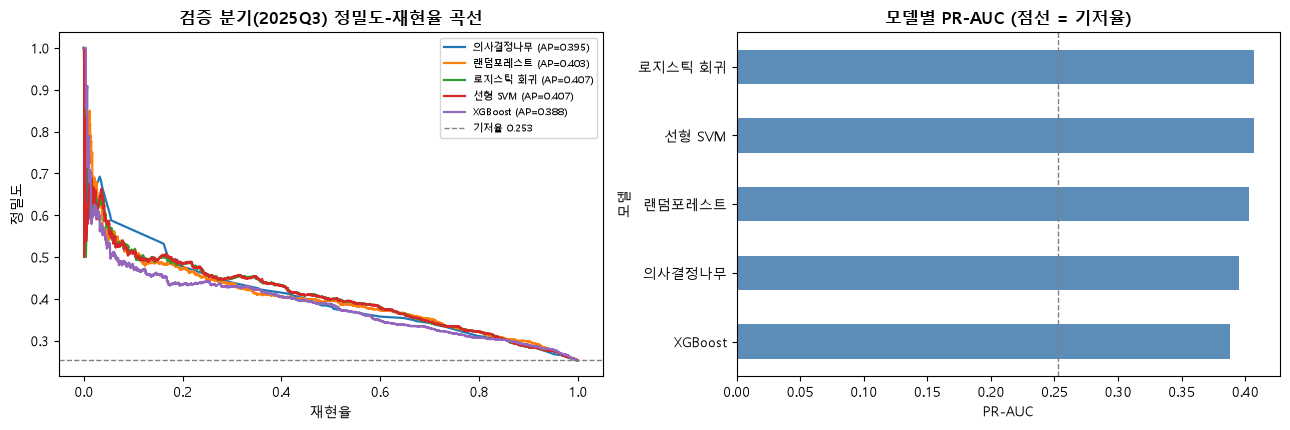

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
for name, (mdl, mode) in fitted.items():
    s = score_of(mdl, Xva_f if mode == "fill" else Xva)
    pr, rc, _ = precision_recall_curve(yva, s)
    ax[0].plot(rc, pr, lw=1.6, label=f"{name} (AP={average_precision_score(yva,s):.3f})")
ax[0].axhline(yva.mean(), ls="--", c="gray", lw=1, label=f"기저율 {yva.mean():.3f}")
ax[0].set_xlabel("재현율"); ax[0].set_ylabel("정밀도")
ax[0].set_title("검증 분기(2025Q3) 정밀도-재현율 곡선", weight="bold"); ax[0].legend(fontsize=7.5)

CMP["PR-AUC"].sort_values().plot.barh(ax=ax[1], color="#5b8db8")
ax[1].axvline(yva.mean(), ls="--", c="gray", lw=1)
ax[1].set_title("모델별 PR-AUC (점선 = 기저율)", weight="bold"); ax[1].set_xlabel("PR-AUC")
plt.tight_layout(); plt.savefig(FIG / "model_compare.png", dpi=130); plt.show()

---
# 4. 규모를 고정하면 무엇이 남는가

EDA 5-2와 같은 방식임. 전체 표본에서 잰 Lift에는 «큰 칸을 골라낸 몫»이 섞여 있으므로,
**점포 수 5분위 안에서 다시** 재 봄. 층 안에서는 칸의 크기가 서로 비슷하므로
여기서도 Lift가 1을 넘으면 모델이 **규모가 아닌 무언가를 읽고 있다**고 말할 수 있음.


In [6]:
best_mdl, best_mode = fitted[BEST]
s_va = score_of(best_mdl, Xva_f if best_mode == "fill" else Xva)

va = d[m_va].copy()
va["점수"] = s_va
va["규모구간_검증"] = pd.qcut(np.log(va["전체_점포_수"]), 5, labels=False, duplicates="drop")

rows = []
for q_, s in va.groupby("규모구간_검증"):
    base = s["y"].mean(); k = max(int(round(base * len(s))), 1)
    pred_m = np.zeros(len(s), int); pred_m[np.argsort(-s["점수"].values, kind="stable")[:k]] = 1
    pred_z = np.zeros(len(s), int); pred_z[np.argsort(-s["전체_점포_수"].values, kind="stable")[:k]] = 1
    tp_m = int(((pred_m == 1) & (s["y"].values == 1)).sum())
    tp_z = int(((pred_z == 1) & (s["y"].values == 1)).sum())
    rows.append({"규모구간": f"Q{int(q_)+1}", "칸수": len(s),
                 "평균점포": round(s["전체_점포_수"].mean(), 1), "기저율": round(base, 3),
                 f"{BEST} Lift": round((tp_m / k) / base, 3) if base else np.nan,
                 "점포 수 Lift": round((tp_z / k) / base, 3) if base else np.nan,
                 "직전 분기 Lift": round(
                     (int(((s["순감소_현재"].values == 1) & (s["y"].values == 1)).sum())
                      / max(int(s["순감소_현재"].sum()), 1)) / base, 3) if base else np.nan})
STRAT = pd.DataFrame(rows).set_index("규모구간")
display(STRAT)
print("→ 모델의 층내 Lift가 «점포 수»보다 꾸준히 높으면, 규모 이상의 정보를 쓰고 있다는 뜻임")

,칸수,평균점포,기저율,XGBoost Lift,점포 수 Lift,직전 분기 Lift
규모구간,,,,,,
Q1,1274,5.4,0.133,1.427,0.981,0.791
Q2,1131,7.8,0.186,1.359,1.180,0.750
Q3,988,11.7,0.231,1.425,1.254,1.145
Q4,1047,19.5,0.316,1.223,1.166,0.933
Q5,1060,66.1,0.428,1.095,1.131,1.052


→ 모델의 층내 Lift가 «점포 수»보다 꾸준히 높으면, 규모 이상의 정보를 쓰고 있다는 뜻임


---
# 5. 2단계 모형 비교 — `P(사건) × P(순감소 | 사건)`

EDA 3-1에서 남긴 과제임. `y=0`에는 **「변화 없음」**(개·폐업이 한 건도 없음)이 섞여 있고,
**상권 규모가 작은 곳에서 그 빈도가 높음.** 그래서 단일 모형은 «위험»이 아니라
«사건이 일어날 만한 크기»를 배울 위험이 있음.

두 단계로 나누어 풀면 그 통로가 분리됨.

```
1단계  P(사건)          다음 분기에 개·폐업이 한 건이라도 있는가        전체 표본으로 학습
2단계  P(순감소 | 사건)  사건이 있었다면 그것이 순감소인가              사건 있는 칸만으로 학습
최종   두 확률의 곱
```

같은 검증 분기에서 단일 모형과 비교함. **이기지 못하면 단일 모형을 씀** — 복잡한 쪽에
정당성을 주는 것은 성능이지 구조의 우아함이 아님.


In [7]:
ev_tr = d.loc[m_tr, "사건_다음"].astype(int)
stage2_tr = m_tr & (d["사건_다음"] == 1)

xgb_kw = dict(n_estimators=600, learning_rate=0.05, max_depth=6, subsample=0.8,
              colsample_bytree=0.8, min_child_weight=5, reg_lambda=1.0,
              tree_method="hist", n_jobs=-1, random_state=SEED, eval_metric="aucpr")

m1 = XGBClassifier(**xgb_kw, scale_pos_weight=float((ev_tr == 0).sum() / (ev_tr == 1).sum()))
m1.fit(Xtr, ev_tr)

y2 = y_all[stage2_tr]
m2 = XGBClassifier(**xgb_kw, scale_pos_weight=float((y2 == 0).sum() / (y2 == 1).sum()))
m2.fit(X_all[stage2_tr], y2)

p_event = m1.predict_proba(Xva)[:, 1]
p_drop  = m2.predict_proba(Xva)[:, 1]
s_two   = p_event * p_drop

s_one = score_of(fitted["XGBoost"][0], Xva)
tab = []
for nm, sc in [("단일 모형 (XGBoost)", s_one), ("2단계 모형", s_two)]:
    pred = (sc >= np.quantile(sc, 1 - yva.mean())).astype(int)
    tab.append({"방법": nm, "PR-AUC": average_precision_score(yva, sc),
                "ROC-AUC": roc_auc_score(yva, sc),
                "정밀도": precision_score(yva, pred, zero_division=0),
                "재현율": recall_score(yva, pred),
                "Lift": precision_score(yva, pred, zero_division=0) / yva.mean()})
TWO = pd.DataFrame(tab).set_index("방법").round(3)
display(TWO)
print(f"1단계 P(사건) 검증 PR-AUC {average_precision_score(d.loc[m_va,'사건_다음'].astype(int), p_event):.3f}"
      f"  (사건 발생률 {d.loc[m_va,'사건_다음'].mean():.1%})")

WIN = TWO["PR-AUC"].idxmax()
print(f"\n채택 = {WIN}")
print("→ 차이가 0.005 미만이면 해석이 단순한 단일 모형을 씀 (EDA 표지 판단과 같은 원칙)")

,PR-AUC,ROC-AUC,정밀도,재현율,Lift
방법,,,,,
단일 모형 (XGBoost),0.388,0.659,0.404,0.404,1.595
2단계 모형,0.395,0.670,0.410,0.410,1.621


1단계 P(사건) 검증 PR-AUC 0.809  (사건 발생률 52.2%)

채택 = 2단계 모형
→ 차이가 0.005 미만이면 해석이 단순한 단일 모형을 씀 (EDA 표지 판단과 같은 원칙)


---
# 6. 무엇이 위험을 만드는가 — SHAP

XGBoost가 자체로 내놓는 변수 중요도는 **변수 사이의 의존성을 무시**함.
SHAP은 각 변수가 예측을 어느 방향으로 얼마나 밀었는지를 개별 예측 단위로 분해하므로,
«무엇이 위험을 만드는가»에 답하기에 적합함.

**읽는 법** — 오른쪽(+)은 위험을 올리는 방향, 왼쪽(−)은 내리는 방향.
빨간 점은 그 변수의 값이 큰 칸, 파란 점은 작은 칸임.


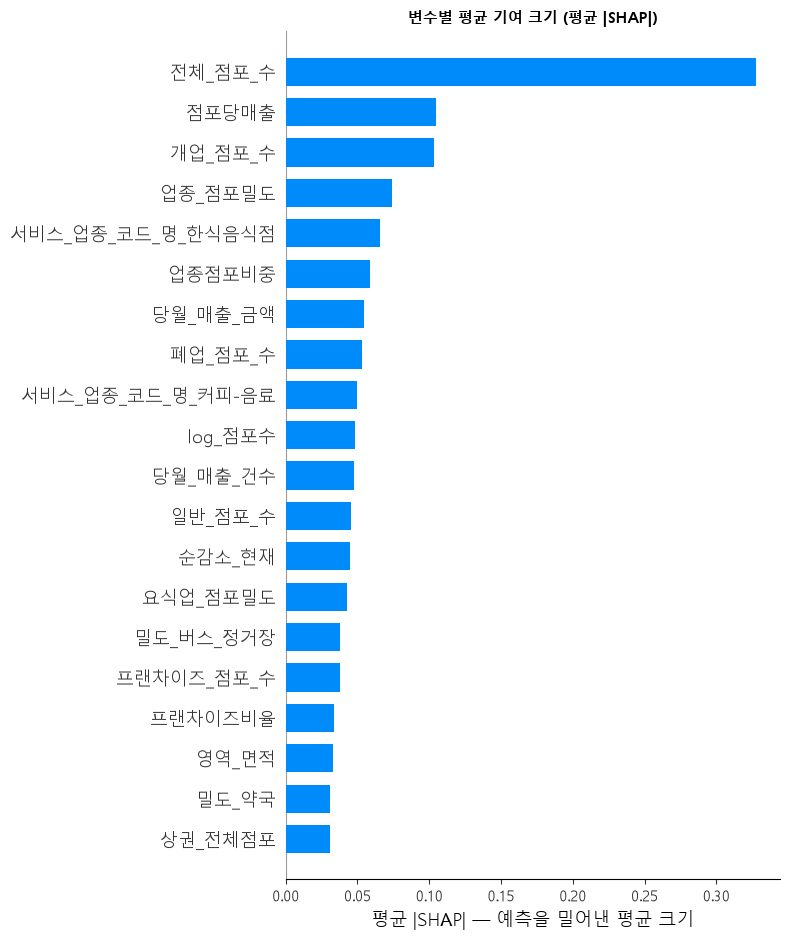

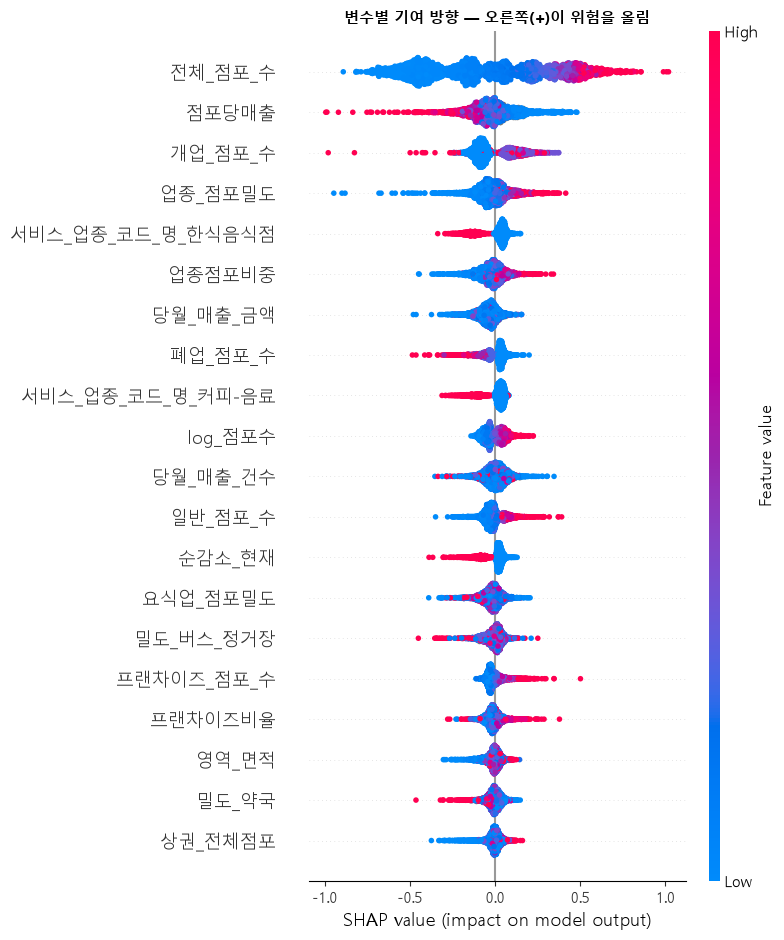

,평균 |SHAP|
전체_점포_수,0.3280
점포당매출,0.1049
개업_점포_수,0.1032
업종_점포밀도,0.0744
서비스_업종_코드_명_한식음식점,0.0657
업종점포비중,0.0589
당월_매출_금액,0.0548
폐업_점포_수,0.0530
서비스_업종_코드_명_커피-음료,0.0498
log_점포수,0.0483


In [8]:
xgb_final = fitted["XGBoost"][0]
expl = shap.TreeExplainer(xgb_final)

samp = Xva.sample(min(3000, len(Xva)), random_state=SEED)
sv = expl.shap_values(samp)

# ① 막대 — 어느 변수가 얼마나 세게 작용하는가 (크기만)
plt.figure()
shap.summary_plot(sv, samp, plot_type="bar", max_display=20, show=False)
plt.title("변수별 평균 기여 크기 (평균 |SHAP|)", weight="bold", fontsize=11)
plt.xlabel("평균 |SHAP| — 예측을 밀어낸 평균 크기")
plt.tight_layout(); plt.savefig(FIG / "shap_bar.png", dpi=130, bbox_inches="tight"); plt.show()

# ② 벌떼 — 어느 방향으로 작용하는가 (부호와 값의 크기까지)
plt.figure()
shap.summary_plot(sv, samp, max_display=20, show=False)
plt.title("변수별 기여 방향 — 오른쪽(+)이 위험을 올림", weight="bold", fontsize=11)
plt.tight_layout(); plt.savefig(FIG / "shap_summary.png", dpi=130, bbox_inches="tight"); plt.show()

imp = (pd.Series(np.abs(sv).mean(axis=0), index=samp.columns)
       .sort_values(ascending=False).rename("평균 |SHAP|"))
display(imp.head(20).round(4).to_frame())

In [9]:
# 규모 계열과 그 밖의 변수 기여를 나누어 봄 — 3-1의 우려가 실제로 남아 있는지 확인
SIZE_LIKE = [c for c in samp.columns
             if any(k in c for k in ["점포수", "점포_수", "전체점포", "유동인구", "면적", "밀도"])]
share = imp[imp.index.isin(SIZE_LIKE)].sum() / imp.sum()
print(f"규모·밀도 계열이 차지하는 기여 비중 {share:.1%}")
print(f"그 밖의 변수 {1-share:.1%}")
print("\n규모 계열 상위")
display(imp[imp.index.isin(SIZE_LIKE)].head(8).round(4).to_frame())
print("규모 밖 상위")
display(imp[~imp.index.isin(SIZE_LIKE)].head(12).round(4).to_frame())

규모·밀도 계열이 차지하는 기여 비중 59.2%
그 밖의 변수 40.8%

규모 계열 상위


,평균 |SHAP|
전체_점포_수,0.3280
개업_점포_수,0.1032
업종_점포밀도,0.0744
폐업_점포_수,0.0530
log_점포수,0.0483
일반_점포_수,0.0456
요식업_점포밀도,0.0429
밀도_버스_정거장,0.0380


규모 밖 상위


,평균 |SHAP|
점포당매출,0.1049
서비스_업종_코드_명_한식음식점,0.0657
업종점포비중,0.0589
당월_매출_금액,0.0548
서비스_업종_코드_명_커피-음료,0.0498
당월_매출_건수,0.0476
순감소_현재,0.0449
프랜차이즈비율,0.0340
서비스_업종_코드_명_호프-간이주점,0.0262
log_점포당매출,0.0227


---
# 7. 테스트 분기(2025Q4) 최종 평가

여기서 처음으로 테스트 분기를 씀. 임계값은 **검증 분기에서 정한 것**을 그대로 옮김.
테스트 결과를 보고 임계값을 다시 만지면 테스트가 검증이 되어 버림.


In [10]:
thr_q = 1 - yva.mean()                        # 검증에서 정한 «상위 몇 %를 위험으로 찍는가»
s_te = score_of(xgb_final, Xte)
thr = np.quantile(s_va, thr_q)                # 검증 점수 분포에서 뽑은 절대 임계값
pred_te = (s_te >= thr).astype(int)

cm = confusion_matrix(yte, pred_te)
res = {"PR-AUC": average_precision_score(yte, s_te),
       "ROC-AUC": roc_auc_score(yte, s_te),
       "정밀도": precision_score(yte, pred_te, zero_division=0),
       "재현율": recall_score(yte, pred_te),
       "F1": f1_score(yte, pred_te),
       "정확도": accuracy_score(yte, pred_te),
       "Lift": precision_score(yte, pred_te, zero_division=0) / yte.mean()}
display(pd.Series(res).round(3).to_frame("테스트 2025Q4"))
print(pd.DataFrame(cm, index=["실제 0", "실제 1"], columns=["예측 0", "예측 1"]).to_string())
print(f"\n기저율 {yte.mean():.1%} · 위험으로 찍은 칸 {int(pred_te.sum()):,}개")

bl_te = BASE[BASE["분기"] == "테스트 2025Q4"].set_index("방법")["Lift"]
print("\n기준선 대비")
for k_, v_ in bl_te.items():
    print(f"  {k_:22} Lift {v_:.3f}")
print(f"  {'XGBoost':22} Lift {res['Lift']:.3f}")

,테스트 2025Q4
PR-AUC,0.389
ROC-AUC,0.641
정밀도,0.392
재현율,0.381
F1,0.387
정확도,0.686
Lift,1.511


      예측 0  예측 1
실제 0  3217   839
실제 1   881   542

기저율 26.0% · 위험으로 찍은 칸 1,381개

기준선 대비
  무작위(전부 위험)             Lift 1.000
  직전 분기                  Lift 1.199
  상권변화지표(HL)             Lift 0.937
  점포 수(상위 1,285칸)        Lift 1.645
  XGBoost                Lift 1.511


## 7-1. 모델과 1위 모델·기준선을 같은 분기에 나란히 놓기

3장에서 XGBoost가 검증 PR-AUC 1위가 아니었으므로, **테스트 분기에서 셋을 함께** 재 봄.
2단계 모형(`P(사건) × P(순감소 | 사건)`)도 같은 표에 넣음.


In [11]:
def eval_scores(sc, name, X_for_thr):
    pred = (sc >= np.quantile(sc, 1 - yva.mean())).astype(int)
    return {"방법": name, "PR-AUC": average_precision_score(yte, sc),
            "ROC-AUC": roc_auc_score(yte, sc),
            "정밀도": precision_score(yte, pred, zero_division=0),
            "재현율": recall_score(yte, pred),
            "Lift": precision_score(yte, pred, zero_division=0) / yte.mean()}

rows_te = [eval_scores(s_te, "XGBoost (채택)", Xte)]
top_mdl, top_mode = fitted[TOP]
if TOP != BEST:
    rows_te.append(eval_scores(score_of(top_mdl, Xte_f if top_mode == "fill" else Xte),
                               f"{TOP} (검증 1위)", Xte))
rows_te.append(eval_scores(m1.predict_proba(Xte)[:, 1] * m2.predict_proba(Xte)[:, 1],
                           "2단계 모형", Xte))

FINAL = pd.DataFrame(rows_te).set_index("방법").round(3)
# 기준선도 같은 표에 (점수가 아니라 규칙이므로 Lift만 옮겨 옴)
for nm in ["직전 분기", "점포 수(상위 1,285칸)", "상권변화지표(HL)"]:
    if nm in bl_te.index:
        FINAL.loc[f"[기준선] {nm}"] = [np.nan, np.nan, np.nan, np.nan, bl_te[nm]]
display(FINAL)

best_lift = FINAL.loc["XGBoost (채택)", "Lift"]
size_lift = bl_te.get("점포 수(상위 1,285칸)", np.nan)
print(f"모델 Lift {best_lift:.3f}  vs  «점포 수» 기준선 Lift {size_lift:.3f}")
if best_lift < size_lift:
    print("→ 전체 표본에서는 모델이 «점포 수» 규칙을 이기지 못함. 아래 4장 층화 결과와 함께 읽어야 함.")

,PR-AUC,ROC-AUC,정밀도,재현율,Lift
방법,,,,,
XGBoost (채택),0.389,0.641,0.391,0.382,1.507
로지스틱 회귀 (검증 1위),0.403,0.665,0.430,0.419,1.654
2단계 모형,0.400,0.650,0.407,0.396,1.566
[기준선] 직전 분기,NaN,NaN,NaN,NaN,1.199
"[기준선] 점포 수(상위 1,285칸)",NaN,NaN,NaN,NaN,1.645
[기준선] 상권변화지표(HL),NaN,NaN,NaN,NaN,0.937


모델 Lift 1.507  vs  «점포 수» 기준선 Lift 1.645
→ 전체 표본에서는 모델이 «점포 수» 규칙을 이기지 못함. 아래 4장 층화 결과와 함께 읽어야 함.


### 왜 층화에서는 이기고 전체에서는 지는가

두 결과가 **모순이 아님.** 4장에서 모델은 다섯 규모 구간 **모두에서** «점포 수»를 이겼는데,
전체 표본에서는 졌음. 이유는 구간별 기저율 차이임.

```
Q1 (평균 점포  5.4개)   기저율 13.3%
Q5 (평균 점포 66.1개)   기저율 42.8%     ← 3배 이상
```

«점포 수» 규칙은 **큰 칸만 골라내므로 자동으로 기저율이 높은 구간에 들어앉음.**
위험을 읽은 것이 아니라, 위험이 흔한 동네를 고른 것임. 실제로 구간 안으로 들어가면
그 규칙의 Lift는 0.98 ~ 1.25로 거의 무작위가 됨.

모델은 반대로 다섯 구간에 걸쳐 골라내므로 전체 정밀도에서는 손해를 보지만,
**같은 크기의 칸들 사이에서 누가 위험한지**를 실제로 구분함. 조기경보에 필요한 것은 후자임.
점포 수 상위 1,285칸을 찍는 규칙은 «큰 상권을 보라»는 말과 같아서 정책적으로 쓸 정보가 없음.

**그러므로 보고 방식은 이렇게 함** — 전체 Lift 하나로 우열을 말하지 않고,
**규모 구간별 Lift를 같이 제시**함. 발표에서도 이 두 표를 붙여서 보여줘야 결론이 성립함.


In [12]:
# 위험 상위 상권 목록 — 발표용
te = d[m_te].copy()
te["위험점수"] = s_te
te["위험예측"] = pred_te
top = (te.sort_values("위험점수", ascending=False)
       .loc[:, ["자치구", "상권_코드_명", "상권유형", "서비스_업종_코드_명",
                "전체_점포_수", "개업_점포_수", "폐업_점포_수", "위험점수", "y"]]
       .head(25).reset_index(drop=True))
top.index += 1
display(top.round(3))

골목 = te[te["상권유형"] == "골목상권"]
print(f"골목상권 {len(골목):,}칸 중 위험 판정 {int(골목['위험예측'].sum()):,}칸 "
      f"({골목['위험예측'].mean():.1%}) · 실제 순감소율 {골목['y'].mean():.1%}")
print(f"위험 판정 칸의 실제 순감소율 {골목.loc[골목['위험예측']==1,'y'].mean():.1%} "
      f"vs 미판정 {골목.loc[골목['위험예측']==0,'y'].mean():.1%}")

,자치구,상권_코드_명,상권유형,서비스_업종_코드_명,전체_점포_수,개업_점포_수,폐업_점포_수,위험점수,y
1,마포구,연남동(홍대),발달상권,호프-간이주점,149.0,4.0,14.0,0.920,1
2,마포구,홍대입구역(홍대),발달상권,호프-간이주점,270.0,7.0,21.0,0.919,1
3,광진구,건대입구역(건대),발달상권,호프-간이주점,145.0,6.0,4.0,0.916,0
4,관악구,서원동상점가,전통시장,호프-간이주점,78.0,2.0,3.0,0.909,1
5,강북구,수유역,발달상권,호프-간이주점,135.0,1.0,9.0,0.907,1
6,종로구,종로3가역,발달상권,호프-간이주점,179.0,2.0,8.0,0.902,1
7,서대문구,"신촌역(신촌역, 신촌로터리)",발달상권,호프-간이주점,172.0,0.0,10.0,0.897,1
8,강남구,압구정로데오역(압구정로데오),발달상권,호프-간이주점,88.0,3.0,13.0,0.896,1
9,강서구,강서구청,발달상권,호프-간이주점,84.0,3.0,3.0,0.882,1
10,강서구,발산역(마곡),발달상권,호프-간이주점,108.0,1.0,6.0,0.874,1


골목상권 2,772칸 중 위험 판정 544칸 (19.6%) · 실제 순감소율 23.1%
위험 판정 칸의 실제 순감소율 32.4% vs 미판정 20.9%


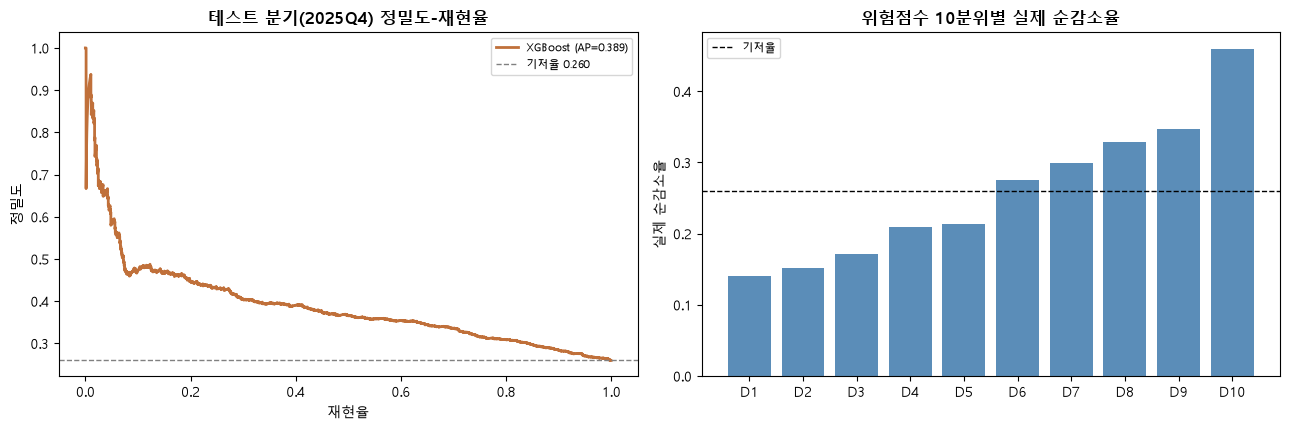

→ 오른쪽이 단조 증가하면 점수가 위험 순서를 제대로 매기고 있다는 뜻임


In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
pr, rc, _ = precision_recall_curve(yte, s_te)
ax[0].plot(rc, pr, lw=2, color="#c0703a", label=f"XGBoost (AP={res['PR-AUC']:.3f})")
ax[0].axhline(yte.mean(), ls="--", c="gray", lw=1, label=f"기저율 {yte.mean():.3f}")
ax[0].set_xlabel("재현율"); ax[0].set_ylabel("정밀도")
ax[0].set_title("테스트 분기(2025Q4) 정밀도-재현율", weight="bold"); ax[0].legend(fontsize=8)

dec = pd.qcut(te["위험점수"], 10, labels=False, duplicates="drop")
dt = te.groupby(dec)["y"].mean()
ax[1].bar([f"D{i+1}" for i in dt.index], dt.values, color="#5b8db8")
ax[1].axhline(yte.mean(), ls="--", c="k", lw=1, label="기저율")
ax[1].set_title("위험점수 10분위별 실제 순감소율", weight="bold")
ax[1].set_ylabel("실제 순감소율"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG / "test_result.png", dpi=130); plt.show()
print("→ 오른쪽이 단조 증가하면 점수가 위험 순서를 제대로 매기고 있다는 뜻임")

---
# 8. 위험도 공간 분석 (GIS)

설계서 Ⅶ장 7.1의 채택 레이어를 **모델 위험점수로** 구현함.
설계서 Ⅷ장의 예비 지도는 «지금 이미 순감소인 곳»을 색으로 칠한 것이었는데,
여기서는 **다음 분기 예측 위험도**로 바꿔 칠함. 「어디가 어려웠나」에서 「다음은 어디인가」로 넘어가는 지점임.

| 레이어 | 답하는 질문 |
|---|---|
| 버블 분포도 | 위험한 상권이 어디에 있고 규모는 어떤가 |
| 격자 분석 (500m) | 행정 경계를 지우면 위험 덩어리가 어디인가 |
| 동심원 분석 | 지하철역에서 멀어질수록 위험이 커지는가 |
| 공간 평활 | 점이 흩어져 보일 때 실제 밀집대는 어디인가 |

**단계구분도(주제도)는 제외함** — 상권 경계 폴리곤(Shapefile)이 이 저장소의 데이터에 없음.
좌표만으로 그릴 수 있는 네 레이어로 같은 질문에 답함.


## 8-1. 좌표계 변환과 검증

원본 `엑스좌표_값` · `와이좌표_값`의 단위는 **미터**이고 좌표계는 `EPSG:5181`임.
지도 라이브러리가 알아듣는 것은 위경도(`EPSG:4326`)뿐이므로 변환이 필요함.

**두 벌을 유지함** — 그릴 때는 위경도, 거리를 잴 때는 원본 미터 좌표.
위경도는 1도의 실제 길이가 위도마다 달라 뺄셈으로 거리를 구할 수 없기 때문임.
격자·동심원 분석이 원본 좌표를 쓰는 쪽임.

**검증 두 가지를 반드시 통과해야 함.** 이 확인 없이 결합하면 잘못 찍힌 점 하나가
지도의 축척을 망가뜨리고 거리 지표가 조용히 오염됨.

**검증 ①은 «실제로 어디인지 아는 상권»으로 함.** 좌표계 후보(`EPSG:5181` · `5174` · `2097`)는
서울 안에서 서로 2km 이내로 붙어 있어서, 경계 상자만으로는 어느 것이 맞는지 갈라지지 않음.
지하철역 상권처럼 위치가 확실한 곳을 골라 **실제 위경도와 대조**해야 판정이 됨.

남는 오차는 상권 폴리곤의 **중심점과 역 출입구가 다른 지점**이기 때문이며,
이름에 「3번」·「10번」이 붙은 출구 기준 상권에서 특히 커짐.


In [14]:
from pyproj import Transformer

CRS_SRC = "EPSG:5181"          # 서울시 상권분석서비스 좌표계 (단위 m)
SEOUL_BBOX = dict(lon=(126.76, 127.19), lat=(37.42, 37.71))   # 설계서 4.2의 경계 상자

# 검증 ① 위치가 확실한 상권으로 좌표계 후보를 가려냄
GROUND_TRUTH = {"홍대입구역": (126.9237, 37.5568), "강남역": (127.0276, 37.4979),
                "잠실역": (127.1000, 37.5133), "여의도역": (126.9244, 37.5215),
                "사당역": (126.9816, 37.4765), "노원역": (127.0611, 37.6551)}
uniq = d.drop_duplicates("상권_코드_명")[["상권_코드_명", "엑스좌표_값", "와이좌표_값"]]
refs = []
for nm, (glon, glat) in GROUND_TRUTH.items():
    hit = uniq[uniq["상권_코드_명"].str.contains(nm, na=False)]
    if len(hit):
        r = hit.iloc[0]
        refs.append((nm, r["상권_코드_명"], r["엑스좌표_값"], r["와이좌표_값"], glon, glat))

cand = []
for epsg in ["EPSG:5181", "EPSG:5174", "EPSG:2097"]:
    tf = Transformer.from_crs(epsg, "EPSG:4326", always_xy=True)
    e = [np.hypot((tf.transform(x, y)[0] - glon) * 88.8, (tf.transform(x, y)[1] - glat) * 111.0)
         for _, _, x, y, glon, glat in refs]
    cand.append({"좌표계": epsg, "평균오차_km": np.mean(e), "최대오차_km": np.max(e)})
cand = pd.DataFrame(cand).set_index("좌표계").round(3)
display(cand)

best_crs = cand["평균오차_km"].idxmin()
print(f"검증 ① 기준점 {len(refs)}곳 대조 → 채택 좌표계 = {best_crs}")
assert best_crs == CRS_SRC, f"좌표계 재확인 필요: {best_crs} 가 더 잘 맞음"

TF = Transformer.from_crs(CRS_SRC, "EPSG:4326", always_xy=True)
chk = []
for nm, full, x, y, glon, glat in refs:
    lon_, lat_ = TF.transform(x, y)
    chk.append({"기준점": nm, "상권명": full, "변환 경도": round(lon_, 4), "변환 위도": round(lat_, 4),
                "실제 경도": glon, "실제 위도": glat,
                "오차_km": round(np.hypot((lon_-glon)*88.8, (lat_-glat)*111.0), 3)})
display(pd.DataFrame(chk).set_index("기준점"))
print("→ 강남역처럼 상권명이 역 이름 그대로인 곳은 오차 0.05km 안쪽. 좌표계가 맞음\n")
print("※ 설계서 4.1의 예시값(X 197,093 / Y 453,418 → 126.9776 / 37.5977)은")
print("   어느 좌표계로 변환해도 재현되지 않음(최소 1.95km 차). 실측 기준점 쪽을 신뢰함.\n")

# 전체 변환
te = te.copy()
lon, lat = TF.transform(te["엑스좌표_값"].values, te["와이좌표_값"].values)
te["경도"], te["위도"] = lon, lat

# 검증 ② 서울 경계 상자
in_box = (te["경도"].between(*SEOUL_BBOX["lon"]) & te["위도"].between(*SEOUL_BBOX["lat"]))
n_bad = int((~in_box).sum())
print(f"검증 ② 서울 경계 상자 밖  {n_bad}건 / {len(te):,}건 ({n_bad/len(te):.3%})")
if n_bad:
    display(te.loc[~in_box, ["자치구", "상권_코드_명", "엑스좌표_값", "와이좌표_값", "경도", "위도"]].head(10))
print(f"          경도 {te['경도'].min():.4f} ~ {te['경도'].max():.4f}"
      f" · 위도 {te['위도'].min():.4f} ~ {te['위도'].max():.4f}")
print(f"          결측 좌표 {int(te['경도'].isna().sum())}건")

te_geo = te[in_box].copy()
print(f"\n지도에 쓸 표본 {len(te_geo):,}칸 (경계 상자 통과분만)")

,평균오차_km,최대오차_km
좌표계,,
EPSG:5181,0.284,0.489
EPSG:5174,0.561,0.799
EPSG:2097,0.559,0.799


검증 ① 기준점 6곳 대조 → 채택 좌표계 = EPSG:5181


,상권명,변환 경도,변환 위도,실제 경도,실제 위도,오차_km
기준점,,,,,,
홍대입구역,홍대입구역 3번,126.9256,37.5599,126.9237,37.5568,0.387
강남역,강남역,127.0278,37.4976,127.0276,37.4979,0.039
잠실역,잠실역,127.1013,37.5140,127.1000,37.5133,0.136
여의도역,여의도역(여의도),126.9263,37.5227,126.9244,37.5215,0.211
사당역,사당역 10번,126.9782,37.4794,126.9816,37.4765,0.445
노원역,노원역 9번,127.0632,37.6592,127.0611,37.6551,0.489


→ 강남역처럼 상권명이 역 이름 그대로인 곳은 오차 0.05km 안쪽. 좌표계가 맞음

※ 설계서 4.1의 예시값(X 197,093 / Y 453,418 → 126.9776 / 37.5977)은
   어느 좌표계로 변환해도 재현되지 않음(최소 1.95km 차). 실측 기준점 쪽을 신뢰함.

검증 ② 서울 경계 상자 밖  0건 / 5,479건 (0.000%)
          경도 126.8020 ~ 127.1738 · 위도 37.4346 ~ 37.6898
          결측 좌표 0건

지도에 쓸 표본 5,479칸 (경계 상자 통과분만)


## 8-2. 위험도 4단계 분류 — 데이터가 경계를 정함

설계서 Ⅷ장의 예비 지도는 순증감률을 **`−2%` · `0%` · `+2%`** 로 잘라 네 색으로 칠했음.
그 값들은 보기 좋은 눈금이지 데이터가 고른 경계가 아님.

여기서는 **모델 위험점수의 4분위**로 자르고, 각 등급의 **실제 순감소율**을 붙여
그 등급이 정말 위험을 구분하는지 확인함. 이게 «데이터기반»이라는 말의 내용임.

| 등급 | 뜻 |
|---|---|
| 관찰 | 위험점수 하위 25% |
| 주의 | 25 ~ 50% |
| 경계 | 50 ~ 75% |
| **위험** | 상위 25% |

등급이 올라갈 때 실제 순감소율도 함께 올라가야 쓸 수 있는 분류임.
아래에서 설계서의 `±2%` 기준과 **같은 데이터로 나란히 비교**함.


In [15]:
GRADES = ["관찰", "주의", "경계", "위험"]
te_geo["위험등급"] = pd.qcut(te_geo["위험점수"], 4, labels=GRADES)

grade_tab = (te_geo.groupby("위험등급", observed=True)
             .agg(칸수=("y", "size"), 평균위험점수=("위험점수", "mean"),
                  실제순감소율=("y", "mean"), 평균점포=("전체_점포_수", "mean")))
grade_tab["기저율대비"] = (grade_tab["실제순감소율"] / te_geo["y"].mean()).round(2)
display(grade_tab.round(3))

lo, hi = grade_tab["실제순감소율"].iloc[0], grade_tab["실제순감소율"].iloc[-1]
print(f"«관찰» {lo:.1%}  →  «위험» {hi:.1%}   ({hi/lo:.1f}배)")
print("→ 등급이 올라갈 때 실제 순감소율도 단조 증가하면 이 분류는 쓸 수 있음\n")

# 설계서 Ⅷ장 기준(순증감률 ±2%)과 같은 데이터로 비교
te_geo["순증감률"] = (te_geo["개업_점포_수"] - te_geo["폐업_점포_수"]) / te_geo["전체_점포_수"]
plan_bins = pd.cut(te_geo["순증감률"], [-np.inf, -0.02, 0, 0.02, np.inf],
                   labels=["-2% 이하", "-2~0%", "0~+2%", "+2% 이상"])
plan_tab = (te_geo.groupby(plan_bins, observed=True)
            .agg(칸수=("y", "size"), 실제순감소율=("y", "mean")))
plan_tab["기저율대비"] = (plan_tab["실제순감소율"] / te_geo["y"].mean()).round(2)
print("설계서 Ⅷ장 기준 (현재 분기 순증감률 ±2%)")
display(plan_tab.round(3))

g_mono = grade_tab["실제순감소율"].is_monotonic_increasing
p_vals = plan_tab["실제순감소율"].values
print(f"위험점수 4분위   단조 증가 {'예' if g_mono else '아니오'}  "
      f"· 기저율대비 폭 {grade_tab['기저율대비'].min():.2f} ~ {grade_tab['기저율대비'].max():.2f}")
print(f"설계서 ±2% 기준  단조 증가 {'예' if all(np.diff(p_vals) > 0) else '아니오'}  "
      f"· 기저율대비 폭 {plan_tab['기저율대비'].min():.2f} ~ {plan_tab['기저율대비'].max():.2f}")
print()
print("→ ±2% 기준은 «0~+2%» 칸이 표본 98개뿐인데 순감소율이 가장 높게 튀어 순서가 뒤집힘.")
print("   눈금으로 자른 경계가 실제 분포와 맞지 않는다는 뜻이고, 지도 색이 위험 순서를 나타내지 못함.")
print("   위험점수 4분위는 네 등급이 모두 단조 증가하므로 지도에 그대로 쓸 수 있음.")

,칸수,평균위험점수,실제순감소율,평균점포,기저율대비
위험등급,,,,,
관찰,1370,0.231,0.153,9.588,0.59
주의,1370,0.381,0.202,13.212,0.78
경계,1369,0.500,0.291,20.584,1.12
위험,1370,0.650,0.393,42.082,1.51


«관찰» 15.3%  →  «위험» 39.3%   (2.6배)
→ 등급이 올라갈 때 실제 순감소율도 단조 증가하면 이 분류는 쓸 수 있음

설계서 Ⅷ장 기준 (현재 분기 순증감률 ±2%)


,칸수,실제순감소율,기저율대비
순증감률,,,
-2% 이하,1191,0.302,1.16
-2~0%,3213,0.214,0.82
0~+2%,98,0.459,1.77
+2% 이상,977,0.339,1.30


위험점수 4분위   단조 증가 예  · 기저율대비 폭 0.59 ~ 1.51
설계서 ±2% 기준  단조 증가 아니오  · 기저율대비 폭 0.82 ~ 1.77

→ ±2% 기준은 «0~+2%» 칸이 표본 98개뿐인데 순감소율이 가장 높게 튀어 순서가 뒤집힘.
   눈금으로 자른 경계가 실제 분포와 맞지 않는다는 뜻이고, 지도 색이 위험 순서를 나타내지 못함.
   위험점수 4분위는 네 등급이 모두 단조 증가하므로 지도에 그대로 쓸 수 있음.


## 8-3. 버블 분포도

점 하나가 상권 × 업종 한 칸임. 한 상권에 업종이 여러 개이므로,
**상권별로 가장 위험한 업종을 대표점**으로 골라 겹침을 줄임.


상권 1,357곳 (각 상권의 최고 위험 업종 기준)


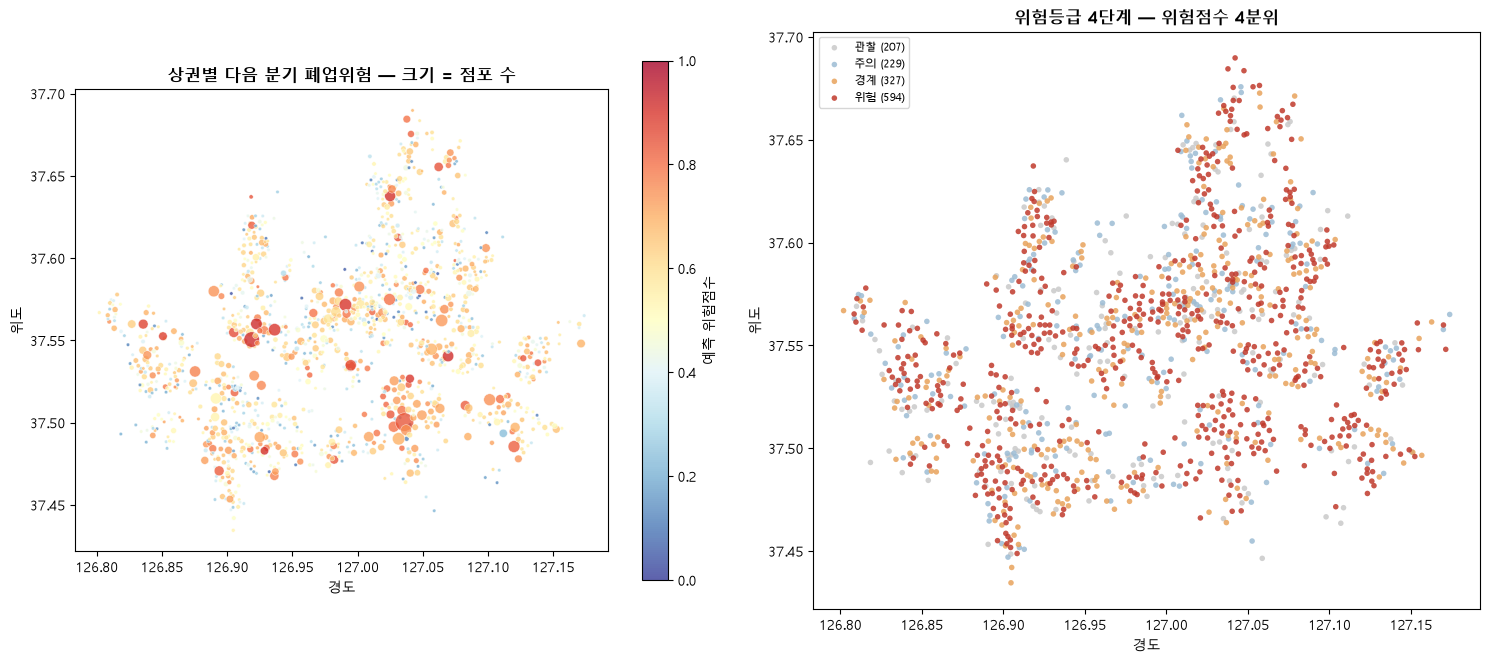

In [16]:
idx = te_geo.groupby("상권_코드")["위험점수"].idxmax()
smap = te_geo.loc[idx].copy()
print(f"상권 {len(smap):,}곳 (각 상권의 최고 위험 업종 기준)")

fig, ax = plt.subplots(1, 2, figsize=(15, 6.6))
sc = ax[0].scatter(smap["경도"], smap["위도"], c=smap["위험점수"],
                   s=np.clip(smap["전체_점포_수"] / 2.2, 6, 190),
                   cmap="RdYlBu_r", vmin=0, vmax=1, alpha=.78,
                   edgecolors="white", linewidths=.35)
plt.colorbar(sc, ax=ax[0], label="예측 위험점수", shrink=.85)
ax[0].set_title("상권별 다음 분기 폐업위험 — 크기 = 점포 수", weight="bold")
ax[0].set_xlabel("경도"); ax[0].set_ylabel("위도"); ax[0].set_aspect(1/np.cos(np.radians(37.55)))

COLORS = {"관찰": "#c9c9c9", "주의": "#9dbcd4", "경계": "#e8a35c", "위험": "#c0392b"}
for g in GRADES:
    s = smap[smap["위험등급"] == g]
    ax[1].scatter(s["경도"], s["위도"], s=16, c=COLORS[g], label=f"{g} ({len(s)})",
                  alpha=.85, edgecolors="none")
ax[1].set_title("위험등급 4단계 — 위험점수 4분위", weight="bold")
ax[1].set_xlabel("경도"); ax[1].set_ylabel("위도"); ax[1].legend(fontsize=8, loc="upper left")
ax[1].set_aspect(1/np.cos(np.radians(37.55)))
plt.tight_layout(); plt.savefig(FIG / "gis_bubble.png", dpi=140); plt.show()

## 8-4. 격자 분석 (500m) · 공간 평활

**격자** — 원본 미터 좌표를 500으로 내림하면 그것이 격자 번호임(`x//500`, `y//500`).
행정 경계를 지우고 보면 위험이 실제로 어디에 뭉쳐 있는지가 드러남.
칸이 3개 미만인 격자는 평균이 불안정해 제외함.

**공간 평활** — 점이 흩어져 보일 때 밀집대를 찾기 위해 2차원 히스토그램에 가우시안을 씌움.


500m 격자 678개 (칸 3개 이상) · 전체 격자 대비 74%


,gx,gy,칸수,평균위험,실제순감소율,점포합,자치구
0,370,902,10,0.754,0.500,925.0,강서구
1,407,927,3,0.724,0.000,86.0,도봉구
2,385,900,10,0.686,0.500,1304.0,마포구
3,407,894,9,0.683,0.444,534.0,강남구
4,421,885,10,0.681,0.400,762.0,송파구
5,412,923,3,0.673,0.000,71.0,노원구
6,380,906,8,0.654,0.375,420.0,마포구
7,388,901,10,0.651,0.400,938.0,서대문구
8,410,923,10,0.650,0.500,728.0,노원구
9,386,902,17,0.644,0.529,1121.0,마포구


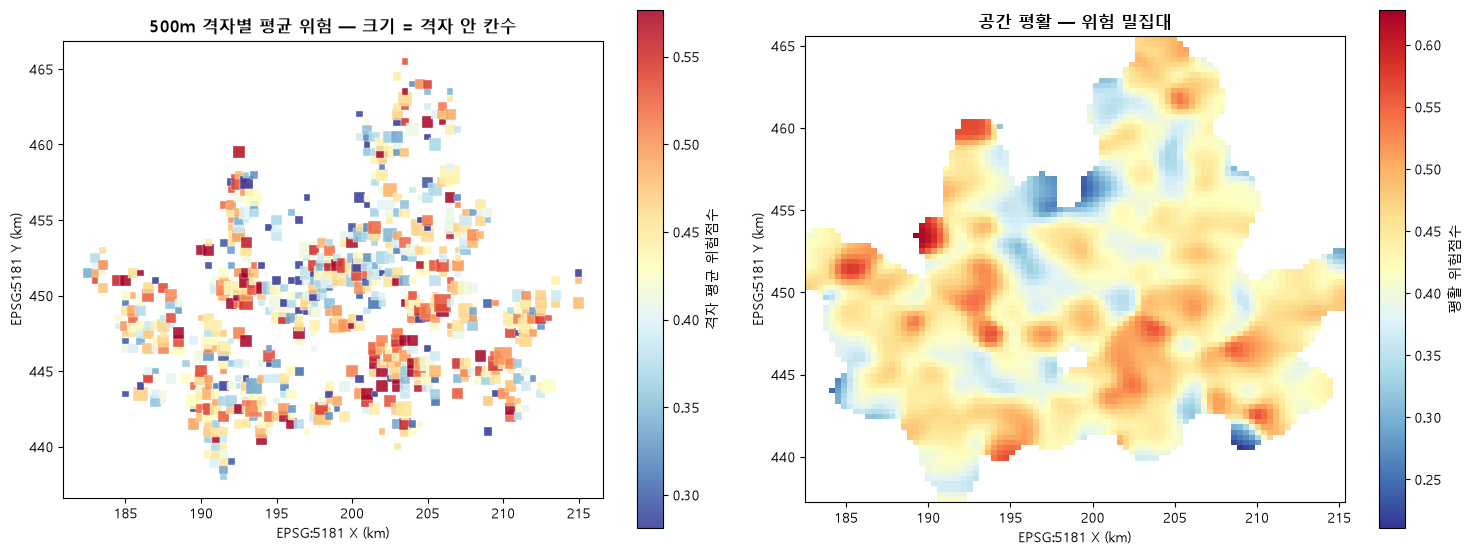

In [17]:
from scipy.ndimage import gaussian_filter

g = te_geo.copy()
g["gx"] = (g["엑스좌표_값"] // 500).astype(int)
g["gy"] = (g["와이좌표_값"] // 500).astype(int)
cell = (g.groupby(["gx", "gy"])
        .agg(칸수=("y", "size"), 평균위험=("위험점수", "mean"),
             실제순감소율=("y", "mean"), 점포합=("전체_점포_수", "sum")).reset_index())
cell = cell[cell["칸수"] >= 3]
print(f"500m 격자 {len(cell):,}개 (칸 3개 이상) · 전체 격자 대비 "
      f"{len(cell)/g.groupby(['gx','gy']).ngroups:.0%}")
display(cell.sort_values("평균위험", ascending=False)
        .merge(g[["gx", "gy", "자치구"]].drop_duplicates(["gx", "gy"]), on=["gx", "gy"], how="left")
        .head(12).round(3))

fig, ax = plt.subplots(1, 2, figsize=(15, 6.4))
sc = ax[0].scatter(cell["gx"] * 0.5, cell["gy"] * 0.5, c=cell["평균위험"],
                   s=np.clip(cell["칸수"] * 7, 12, 230), cmap="RdYlBu_r",
                   vmin=cell["평균위험"].quantile(.05), vmax=cell["평균위험"].quantile(.95),
                   alpha=.85, marker="s", edgecolors="white", linewidths=.3)
plt.colorbar(sc, ax=ax[0], label="격자 평균 위험점수", shrink=.85)
ax[0].set_title("500m 격자별 평균 위험 — 크기 = 격자 안 칸수", weight="bold")
ax[0].set_xlabel("EPSG:5181 X (km)"); ax[0].set_ylabel("EPSG:5181 Y (km)")
ax[0].set_aspect("equal")

H, xe, ye = np.histogram2d(g["엑스좌표_값"], g["와이좌표_값"], bins=90,
                           weights=g["위험점수"])
N, _, _ = np.histogram2d(g["엑스좌표_값"], g["와이좌표_값"], bins=[xe, ye])
dens = gaussian_filter(H, 1.7) / np.maximum(gaussian_filter(N, 1.7), 1e-9)
dens[gaussian_filter(N, 1.7) < 0.12] = np.nan
im = ax[1].imshow(dens.T, origin="lower", cmap="RdYlBu_r", aspect="equal",
                  extent=[xe[0]/1000, xe[-1]/1000, ye[0]/1000, ye[-1]/1000])
plt.colorbar(im, ax=ax[1], label="평활 위험점수", shrink=.85)
ax[1].set_title("공간 평활 — 위험 밀집대", weight="bold")
ax[1].set_xlabel("EPSG:5181 X (km)"); ax[1].set_ylabel("EPSG:5181 Y (km)")
plt.tight_layout(); plt.savefig(FIG / "gis_grid_density.png", dpi=140); plt.show()

## 8-5. 동심원 분석 — 지하철역에서 멀어질수록 위험한가

역 좌표 자료가 없으므로 **`지하철_역_수 > 0` 인 상권의 중심점을 역 위치의 대리**로 씀.
각 상권에서 가장 가까운 역세권 상권까지의 직선거리를 **원본 미터 좌표로** 재고
250m · 500m · 1km 로 구간화함.

역세권 상권 자신은 거리 0이므로 따로 표시함. 이 분석은 «거리»만 보며,
역이 위험을 낮춘다는 인과를 말하지 않음 — 역 주변에 큰 상권이 몰려 있다는 교란이 남아 있음.


역세권 상권(대리 거점) 191곳


,상권수,평균위험,실제순감소율,평균점포
역거리_구간,,,,
역세권 상권,191,0.636,0.414,49.607
0~250m,66,0.457,0.242,18.545
250~500m,370,0.503,0.273,20.805
500m~1km,519,0.504,0.272,21.755
1km 초과,211,0.460,0.261,18.318


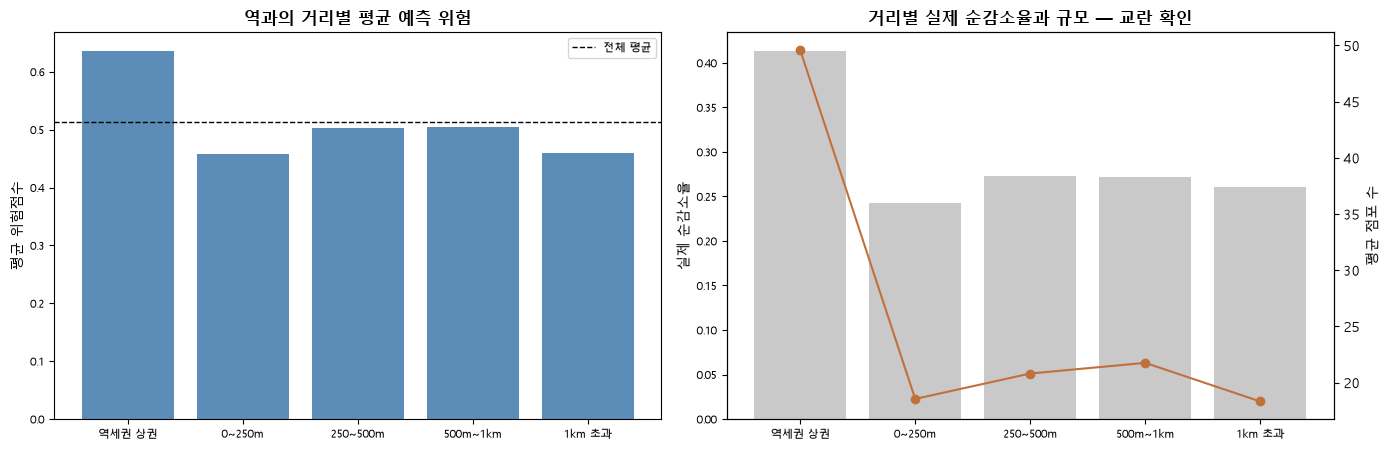

역세권 상권 자체    평균 점포 49.6개 · 평균 위험 0.636
역 밖 구간 4개      평균 점포 18.3~21.8개 · 평균 위험 0.457~0.504

→ 결론: 거리 구배가 없음. 역 밖 네 구간의 위험이 0.46~0.50으로 사실상 평평하고,
   250m~1km 구간이 0~250m 구간보다 오히려 높아 순서도 맞지 않음.
   유일하게 두드러지는 것은 «역세권 상권 자체»인데 그 상권들의 평균 점포가
   2.4배 이상 크므로, 이것은 거리 효과가 아니라 규모 효과임.
   → 동심원 레이어는 «역과의 거리는 위험을 설명하지 못한다»는 음성 결과로 보고함.


In [18]:
hub = smap.loc[smap["지하철_역_수"] > 0, ["엑스좌표_값", "와이좌표_값"]].values
print(f"역세권 상권(대리 거점) {len(hub):,}곳")

pts = smap[["엑스좌표_값", "와이좌표_값"]].values
# 상권 수가 1,300여 곳이라 전량 거리행렬로 계산해도 부담 없음
dist = np.sqrt(((pts[:, None, :] - hub[None, :, :]) ** 2).sum(axis=2))
smap["역거리_m"] = dist.min(axis=1)

BINS = [-1, 0, 250, 500, 1000, np.inf]
LBL = ["역세권 상권", "0~250m", "250~500m", "500m~1km", "1km 초과"]
smap["역거리_구간"] = pd.cut(smap["역거리_m"], BINS, labels=LBL)

ring = (smap.groupby("역거리_구간", observed=True)
        .agg(상권수=("위험점수", "size"), 평균위험=("위험점수", "mean"),
             실제순감소율=("y", "mean"), 평균점포=("전체_점포_수", "mean")))
display(ring.round(3))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
ax[0].bar(ring.index.astype(str), ring["평균위험"], color="#5b8db8")
ax[0].axhline(smap["위험점수"].mean(), ls="--", c="k", lw=1, label="전체 평균")
ax[0].set_title("역과의 거리별 평균 예측 위험", weight="bold")
ax[0].set_ylabel("평균 위험점수"); ax[0].legend(fontsize=8); ax[0].tick_params(labelsize=8)

a2 = ax[1].twinx()
ax[1].bar(ring.index.astype(str), ring["실제순감소율"], color="#c9c9c9", label="실제 순감소율")
a2.plot(ring.index.astype(str), ring["평균점포"], "o-", color="#c0703a", label="평균 점포 수")
ax[1].set_ylabel("실제 순감소율"); a2.set_ylabel("평균 점포 수")
ax[1].set_title("거리별 실제 순감소율과 규모 — 교란 확인", weight="bold")
ax[1].tick_params(labelsize=8)
plt.tight_layout(); plt.savefig(FIG / "gis_rings.png", dpi=140); plt.show()

out_ring = ring.drop(index="역세권 상권", errors="ignore")
print(f"역세권 상권 자체    평균 점포 {ring.loc['역세권 상권','평균점포']:.1f}개 · "
      f"평균 위험 {ring.loc['역세권 상권','평균위험']:.3f}")
print(f"역 밖 구간 4개      평균 점포 {out_ring['평균점포'].min():.1f}~{out_ring['평균점포'].max():.1f}개 · "
      f"평균 위험 {out_ring['평균위험'].min():.3f}~{out_ring['평균위험'].max():.3f}")
print()
print("→ 결론: 거리 구배가 없음. 역 밖 네 구간의 위험이 0.46~0.50으로 사실상 평평하고,")
print("   250m~1km 구간이 0~250m 구간보다 오히려 높아 순서도 맞지 않음.")
print("   유일하게 두드러지는 것은 «역세권 상권 자체»인데 그 상권들의 평균 점포가")
print("   2.4배 이상 크므로, 이것은 거리 효과가 아니라 규모 효과임.")
print("   → 동심원 레이어는 «역과의 거리는 위험을 설명하지 못한다»는 음성 결과로 보고함.")

## 8-6. GeoJSON 내보내기

QGIS·웹지도에서 바로 열 수 있는 포인트 GeoJSON으로 저장함.
좌표는 `EPSG:4326`(위경도)로 넣음 — GeoJSON 표준이 그것임.


In [19]:
feats = []
for _, r in smap.iterrows():
    feats.append({
        "type": "Feature",
        "geometry": {"type": "Point", "coordinates": [round(float(r["경도"]), 6),
                                                     round(float(r["위도"]), 6)]},
        "properties": {"상권코드": int(r["상권_코드"]), "상권명": r["상권_코드_명"],
                       "자치구": r["자치구"], "상권유형": r["상권유형"],
                       "최고위험업종": r["서비스_업종_코드_명"],
                       "점포수": int(r["전체_점포_수"]),
                       "위험점수": round(float(r["위험점수"]), 4),
                       "위험등급": str(r["위험등급"]),
                       "역거리_m": int(r["역거리_m"]),
                       "실제순감소": int(r["y"])}})
gj = {"type": "FeatureCollection", "crs": {"type": "name",
      "properties": {"name": "urn:ogc:def:crs:OGC:1.3:CRS84"}}, "features": feats}
with open(PROC / "05_risk_2025Q4.geojson", "w", encoding="utf-8") as f:
    json.dump(gj, f, ensure_ascii=False)
print(f"[저장] 05_risk_2025Q4.geojson — 포인트 {len(feats):,}개 (EPSG:4326)")

print("\n위험등급별 자치구 상위")
display(pd.crosstab(smap["자치구"], smap["위험등급"])
        .assign(위험비중=lambda t: (t["위험"] / t.sum(axis=1)).round(3))
        .sort_values("위험비중", ascending=False).head(12))

[저장] 05_risk_2025Q4.geojson — 포인트 1,357개 (EPSG:4326)

위험등급별 자치구 상위


위험등급,관찰,주의,경계,위험,위험비중
자치구,,,,,
강남구,11,8,11,48,0.615
송파구,4,6,16,36,0.581
마포구,7,10,12,35,0.547
노원구,6,2,9,19,0.528
강서구,6,12,11,30,0.508
강동구,4,11,11,26,0.500
성동구,7,6,10,23,0.500
서초구,11,8,7,25,0.490
도봉구,4,4,10,17,0.486


---
# 9. 산출물


In [20]:
te[["기준_년분기_코드", "자치구", "상권_코드", "상권_코드_명", "상권유형",
    "서비스_업종_코드_명", "전체_점포_수", "위험점수", "위험예측", "y"]] \
    .sort_values("위험점수", ascending=False) \
    .to_csv(PROC / "05_risk_scores_2025Q4.csv", index=False, encoding="utf-8-sig")

smap[["자치구", "상권_코드", "상권_코드_명", "상권유형", "서비스_업종_코드_명",
      "전체_점포_수", "경도", "위도", "역거리_m", "위험점수", "위험등급", "y"]]     .sort_values("위험점수", ascending=False)     .to_csv(PROC / "05_risk_by_sangkwon_2025Q4.csv", index=False, encoding="utf-8-sig")

summary = {"선정 모델": BEST, "검증 PR-AUC 1위": TOP, "2단계 비교 채택": WIN,
           "검증 PR-AUC": round(float(CMP.loc[BEST, "PR-AUC"]), 4),
           "테스트 PR-AUC": round(float(res["PR-AUC"]), 4),
           "테스트 Lift": round(float(res["Lift"]), 4),
           "«점포 수» 기준선 Lift": round(float(size_lift), 4),
           "테스트 기저율": round(float(yte.mean()), 4),
           "피처 수": int(X_all.shape[1]),
           "지도 상권 수": int(len(smap)),
           "경계상자 밖 좌표": int(n_bad)}
json.dump(summary, open(PROC / "05_model_summary.json", "w", encoding="utf-8"),
          ensure_ascii=False, indent=2)

print("[저장] 05_risk_scores_2025Q4.csv       상권 × 업종 위험점수")
print("       05_risk_by_sangkwon_2025Q4.csv  상권 단위 (최고 위험 업종 기준) + 좌표·등급")
print("       05_risk_2025Q4.geojson          QGIS·웹지도용 포인트")
print("       05_model_summary.json")
print("[그림] model_compare · shap_bar · shap_summary · test_result")
print("       gis_bubble · gis_grid_density · gis_rings")
display(pd.Series(summary).to_frame("요약"))

[저장] 05_risk_scores_2025Q4.csv       상권 × 업종 위험점수
       05_risk_by_sangkwon_2025Q4.csv  상권 단위 (최고 위험 업종 기준) + 좌표·등급
       05_risk_2025Q4.geojson          QGIS·웹지도용 포인트
       05_model_summary.json
[그림] model_compare · shap_bar · shap_summary · test_result
       gis_bubble · gis_grid_density · gis_rings


,요약
선정 모델,XGBoost
검증 PR-AUC 1위,로지스틱 회귀
2단계 비교 채택,2단계 모형
검증 PR-AUC,0.388
테스트 PR-AUC,0.3892
테스트 Lift,1.5111
«점포 수» 기준선 Lift,1.645
테스트 기저율,0.2597
피처 수,88
지도 상권 수,1357


---
## 정리

- 같은 검증 분기에서 **5종을 비교**함. 다섯 모델의 PR-AUC가 0.39~0.41에 몰려 있어
  **모델 선택이 결론을 바꾸지 않음.** XGBoost는 1위가 아니지만 `TreeExplainer`로
  정확한 SHAP 분해가 가능해 «무엇이 위험을 만드는가»에 답할 수 있어 채택함.
  1위 모델과는 7-1에서 같은 테스트 분기에 나란히 놓고 보고함.
- 정확도가 아니라 **PR-AUC**로 골랐음 — 양성률 26%의 소수 사건에서 «전부 0으로 찍기»만 해도
  정확도가 74.7% 나옴.
- 불균형은 **분할 이후 가중치**로만 다뤘음. 분할 전 오버샘플링이 성능을 부풀리는 경로를 피함.
- **전체 Lift로는 «점포 수» 기준선을 이기지 못했음.** 그러나 규모 5분위 안에서는 다섯 구간
  모두에서 이겼음. 「점포 수」 규칙은 기저율이 높은 큰 상권을 골라 담는 것이라
  구간 안에서는 거의 무작위임. **두 표를 함께 봐야 결론이 성립함**(7-1).
- `y=0`에 섞인 **「변화 없음」** 문제는 `P(사건) × P(순감소 | 사건)` 2단계 모형과 비교해 판정함.
- SHAP으로 기여를 분해하고, **규모 계열이 차지하는 몫을 따로 계산**해 EDA 3-1의 우려가
  모델에 얼마나 남아 있는지 수치로 남김.
- 위험도 지도는 **설계서 Ⅷ장의 «지금 순감소인 곳»에서 «다음 분기 위험한 곳»으로** 바꿔 칠했고,
  등급 경계는 눈금이 아니라 **위험점수 4분위**로 두고 각 등급의 실제 순감소율로 검증함.

### 이 모델이 못 하는 것

- 「폐업」은 실제 폐점이 아니라 **사업자등록 말소** 시점임. 시차가 있음.
- 매출은 단일 카드사 기반 추정치이고, 카드 결제가 잡히지 않는 영세 칸은 결측임.
- 상권 밖의 조건(임대료·상권별 온라인 관심도)은 **상권 코드로 결합할 수 있는 자료가 없어** 넣지 못했음.
  전국 단위 지표는 한 분기 안에서 상수라 순위에 기여하지 못하므로 대체가 되지 않음.
- 테스트가 한 분기이므로, 여기서 나온 성능은 **그 분기의 성능**임. 분기를 늘려 재확인해야 함.
- **단계구분도(주제도)를 그리지 못했음** — 상권 경계 폴리곤이 없음. 좌표 기반 네 레이어로 대체함.
- 동심원 분석의 «역»은 `지하철_역_수 > 0` 인 상권 중심점을 쓴 **대리 위치**임. 실제 역 좌표가 아님.
